In [1]:
import cvxpy as cp
from itertools import permutations
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
import warnings
import time
warnings.filterwarnings("ignore")

In [2]:
n_user = 3
h_bad =  0.1
h_good = 1
pr_h_bad = 0.5
pr_h_good = (1- pr_h_bad)
r_max = 2
rho = np.arange(0, r_max+1, 1)
print('rho', rho)

sigma = 0.5

lambda_val, P_bar, D_bar = 0.9, 2, 1

pkt_prob = n_user*[lambda_val]
weights = n_user*[1/n_user]
P_bar_U = n_user*[P_bar]
D_bar_U = n_user*[D_bar]

#####################################################
h_vec_u1 = np.array([h_bad,  h_good]).tolist()
permutations_list = []
permutations_list.extend(list(product(h_vec_u1, repeat=n_user )))
combined_h_vec = []
for permutation in permutations_list:
    arr = []
    for k in permutation:
        arr.append(k)
    combined_h_vec.append(arr)
p_h_u1 = np.array([pr_h_bad, pr_h_good])
permutations_list = []
permutations_list.extend(list(product(p_h_u1, repeat=n_user )))
pr_h = []
for permutation in permutations_list:
    arr = []
    for k in permutation:
        arr.append(k)
    pr_h.append(np.prod(arr))
hp = pr_h
h = combined_h_vec
print('h:', h)
print('prob h:', hp)

rho [0 1 2]
h: [[0.1, 0.1, 0.1], [0.1, 0.1, 1.0], [0.1, 1.0, 0.1], [0.1, 1.0, 1.0], [1.0, 0.1, 0.1], [1.0, 0.1, 1.0], [1.0, 1.0, 0.1], [1.0, 1.0, 1.0]]
prob h: [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125]


In [3]:
W = list(product(rho, repeat=n_user))
rho_DO = []
poss_dec_ord = [(1, 2, 3), (1, 3, 2), (2, 1, 3), (2, 3, 1), (3, 1, 2), (3, 2, 1)]
for w in W:
    for DO in poss_dec_ord:
        rho_DO.append([w, DO])
print('rho, DO:', rho_DO)

rho, DO: [[(0, 0, 0), (1, 2, 3)], [(0, 0, 0), (1, 3, 2)], [(0, 0, 0), (2, 1, 3)], [(0, 0, 0), (2, 3, 1)], [(0, 0, 0), (3, 1, 2)], [(0, 0, 0), (3, 2, 1)], [(0, 0, 1), (1, 2, 3)], [(0, 0, 1), (1, 3, 2)], [(0, 0, 1), (2, 1, 3)], [(0, 0, 1), (2, 3, 1)], [(0, 0, 1), (3, 1, 2)], [(0, 0, 1), (3, 2, 1)], [(0, 0, 2), (1, 2, 3)], [(0, 0, 2), (1, 3, 2)], [(0, 0, 2), (2, 1, 3)], [(0, 0, 2), (2, 3, 1)], [(0, 0, 2), (3, 1, 2)], [(0, 0, 2), (3, 2, 1)], [(0, 1, 0), (1, 2, 3)], [(0, 1, 0), (1, 3, 2)], [(0, 1, 0), (2, 1, 3)], [(0, 1, 0), (2, 3, 1)], [(0, 1, 0), (3, 1, 2)], [(0, 1, 0), (3, 2, 1)], [(0, 1, 1), (1, 2, 3)], [(0, 1, 1), (1, 3, 2)], [(0, 1, 1), (2, 1, 3)], [(0, 1, 1), (2, 3, 1)], [(0, 1, 1), (3, 1, 2)], [(0, 1, 1), (3, 2, 1)], [(0, 1, 2), (1, 2, 3)], [(0, 1, 2), (1, 3, 2)], [(0, 1, 2), (2, 1, 3)], [(0, 1, 2), (2, 3, 1)], [(0, 1, 2), (3, 1, 2)], [(0, 1, 2), (3, 2, 1)], [(0, 2, 0), (1, 2, 3)], [(0, 2, 0), (1, 3, 2)], [(0, 2, 0), (2, 1, 3)], [(0, 2, 0), (2, 3, 1)], [(0, 2, 0), (3, 1, 2)], [(0, 2

In [4]:
def cal_pow(R, DO, h_val):
    sorted_list = DO
    pow_vals = np.zeros(len(DO))
    for i in range(len(DO)):
        idx = DO[i]-1
        sum_i_M = np.sum([R[DO[k]-1]  for k in range(i, len(DO))])
        sum_ip1_M = np.sum([R[DO[k]-1] for k in range(min(i+1, len(DO)), len(DO))])
        pow = (2**(sum_i_M) - 2**(sum_ip1_M))/h_val[idx]
        pow_vals[idx] = pow
    return pow_vals

In [5]:
mu = cp.Variable((len(h), len(rho_DO) ), pos = True)
p = []
for x in range(n_user):
    temp  = 0
    for k in range(len(h)):
        for j in range(len(rho_DO)):
            if rho_DO[j][0][x] != 0:
                temp+= mu[k][j] * hp[k]
    p.append(temp)
P_u = []
for x in range(n_user):
    temp = 0
    for k in range(len(h)):
        for j in range( len(rho_DO)):
            temp+= cal_pow(rho_DO[j][0], rho_DO[j][1] , h[k])[x] * mu[k][j] *  hp[k]
    P_u.append(temp)
D_u = []
for x in range(n_user):
    temp = 0
    for k in range(len(h)):
        for j in range( len(rho_DO)):
            bit = rho_DO[j][0][x]
            # temp+= (np.exp(-bit) * mu[k][j] *  hp[k] * int(bit > 0))
            temp+= ((1 - bit/r_max)**(2) * mu[k][j] *  hp[k] * int(bit > 0))
    D_u.append(temp)
obj_fun = 0
for n in range(n_user):
    obj_fun = obj_fun + ( weights[n] *  pkt_prob[n] * (cp.inv_pos(p[n])  -  1 )  )
objective = cp.Minimize(obj_fun)
constraints = []
for n in range(n_user):
    val1 = pkt_prob[n] * (1- p[n])+ p[n]
    constraints.append(D_u[n]*pkt_prob[n] <= D_bar_U[n] * val1)
# if scheme == 'w/ PA':
for n in range(n_user):
    val1 = pkt_prob[n] * (1- p[n])+ p[n]
    constraints.append(P_u[n]*pkt_prob[n] <= P_bar_U[n]*val1 )
# else:
#     for n in range(n_user):
#         constraints.append(P_u[n] <= P_bar_U[n] )
a_val = []
for q in range(len(h)):
    a_val.append( cp.sum([ mu[q][j] for j in range(len(rho_DO))]))
for a in a_val:
    constraints.append(a == 1)
for i in range(len(h)):           
    for j in range(len(rho_DO)):
        constraints.append(0<= mu[i][j])
        constraints.append(mu[i][j] <= 1)
prob = cp.Problem(objective, constraints)
prob.solve()


final_mus =[]
for j in range(len(h)):
    h_mu_vals = []
    for k in range(len(W)):
        h_mu_vals.append(np.round(np.sum(mu[j].value[k*6:(k+1)*6]), 3))
    final_mus.append(h_mu_vals)

print(np.round(prob.value, 4))
# print(final_mus)

0.537


In [6]:
print(np.array(final_mus))

[[0.    0.333 0.    0.333 0.    0.    0.    0.    0.    0.333 0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.   ]
 [0.    0.323 0.    0.    0.338 0.    0.    0.    0.    0.    0.338 0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.   ]
 [0.    0.    0.    0.323 0.338 0.    0.    0.    0.    0.    0.    0.
  0.338 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.   ]
 [0.    0.    0.    0.    1.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.323 0.338 0.
  0.338 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    1.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.   ]
 [0.    0.    0.    0.

In [7]:
# import numpy as np
# def fix_sum_to_one(p):
#     p = np.array(p, dtype=float)
#     diff = 1.0 - p.sum()          # the tiny rounding difference
#     idx = np.argmax(p)            # index of largest probability
#     p[idx] += diff                # add the difference safely
#     return p

# age = np.array([0, 0, 0])
# sum_age = np.array([0, 0, 0])
# pkt_prob = 0.9
# sum_time = 0
# for t in range(1, 100001):
#     pkts =np.random.choice([1, 0], size=3, p=[pkt_prob, (1-pkt_prob)])
#     h_val_test = np.random.choice([5, 0.5], size=3, p=[0.5, 0.5])

#     t_start = time.time()

#     idx = np.where((h == h_val_test).all(axis=1))[0]
#     age += pkts
#     q_state = np.where(age > 0, 1, 0)
#     rho_idx = np.random.choice(np.arange(len(W)), size=1, p=fix_sum_to_one(final_mus[idx[0]]))
#     best_bits = np.array(W[rho_idx[0]])
#     age = age * np.where(best_bits > 0, 0, 1)
#     sum_age+= age
    
#     sum_time+= (time.time() - t_start)
#     if t%10000 == 0:
#             print('lamdbda', pkt_prob, 't', t, 'Avg age:', np.round(np.mean(sum_age)/t, 4))
#             # print('compute time', sum_time/t )


In [82]:
def fix_sum_to_one(p):
    p = np.array(p, dtype=float)
    diff = 1.0 - p.sum()
    idx = np.argmax(p)
    p[idx] += diff
    return p


def trunc_error(sigma, low=-0.03, high=0.03, size=None):
    if sigma == 0:
        return np.zeros(size)
    a = low / sigma
    b = high / sigma
    return truncnorm.rvs(
        a,
        b,
        loc=0,
        scale=sigma,
        size=size
    )


def get_optimal_decoding_order(beta, h_val):
    beta = np.array(beta, dtype=float)
    h_val = np.array(h_val, dtype=float)
    return np.argsort(beta / h_val)


def cal_pow(R, DO, h_val):
    pow_vals = np.zeros(len(DO))
    for i in range(len(DO)):
        idx = DO[i]
        sum_i_M = np.sum([
            R[DO[k]]
            for k in range(i, len(DO))
        ])
        if i == len(DO) - 1:
            sum_ip1_M = 0
        else:
            sum_ip1_M = np.sum([
                R[DO[k]]
                for k in range(i + 1, len(DO))
            ])
        pow_vals[idx] = (
            2**(sum_i_M)
            -
            2**(sum_ip1_M)
        ) / h_val[idx]
    return pow_vals


def check_success_sic(hr, powers, rates, order):
    M = len(order)
    success = np.zeros(M, dtype=int)
    for j in range(M):
        user_j = order[j]
        signal = hr[user_j] * powers[user_j]
        interference = 0.0
        for k in range(j + 1, M):
            user_k = order[k]
            interference += (
                hr[user_k] * powers[user_k]
            )
        sinr = signal / (1 + interference)
        achievable_rate = np.log2(1 + sinr)
        # if achievable_rate >= rates[user_j]:
        #     success[user_j] = 1

        eps = 1e-10

        if achievable_rate + eps >= rates[user_j]:
            success[user_j] = 1
    return success

In [102]:
import numpy as np
from itertools import product
from multiprocessing import Pool, cpu_count
import time


SRP_age = []
sim_age = []

sigma_arr = np.arange(0.01, 0.1, 0.01)
for sigma in sigma_arr:
    n_user = 3
    h_bad = 0.1
    h_good = 1
    pr_h_bad = 0.5
    pr_h_good = 1.0 - pr_h_bad
    r_max = 2
    rho = np.arange(0, r_max + 1)
    P_bar_U = np.full(n_user, 2.0)
    alpha = 0.05
    max_iter = 50000
    pkt_prob = 0.9


    h_values_eff = [
    max(h_bad  - 0.5*sigma,  1e-6),
    max(h_good - 0.5*sigma, 1e-6)]

    h = np.array(
        list(product(h_values_eff, repeat=n_user)),
        dtype=np.float64)

    # print(h)
    num_h = len(h)
    prob_values = [pr_h_bad, pr_h_good]
    hp = np.array([np.prod(p) for p in product(prob_values, repeat=n_user)], dtype=np.float64)
    W = np.array(list(product(rho, repeat=n_user)), dtype=np.float64)
    num_W = len(W)
    psi = (W > 0).astype(np.float64)

    def cal_pow_all(W, beta, h_val):
        M = len(beta)
        order = np.argsort(beta / h_val)
        W_ordered = W[:, order]
        rev_cumsum = np.cumsum(W_ordered[:, ::-1], axis=1)[:, ::-1]
        P = np.zeros_like(W)
        for i in range(M):
            ui = order[i]
            sum_i_M = rev_cumsum[:, i]
            sum_ip1_M = 0 if i == M - 1 else rev_cumsum[:, i + 1]
            P[:, ui] = (2.0 ** sum_i_M - 2.0 ** sum_ip1_M) / h_val[ui]
        return P

    def process_channel_k(args):
        k, lambda_k, v_k = args
        h_k = h[k]
        Pk = cal_pow_all(W, lambda_k, h_k)

        costs = hp[k] * np.sum(
            pkt_prob * lambda_k * Pk
            - v_k * psi
            - lambda_k * P_bar_U * psi * (pkt_prob - 1),
            axis=1
        )

        min_cost = np.min(costs)
        idx = np.where(np.abs(costs - min_cost) < 1e-10)[0]
        mu = np.zeros(num_W)
        mu[idx] = 1.0 / len(idx)

        p_k  = hp[k] * np.sum(mu[:, None] * psi, axis=0)
        Pu_k = hp[k] * np.sum(mu[:, None] * Pk,  axis=0)

        return p_k, Pu_k, mu

    lambda_k = np.full(n_user, 0.1)
    v_k      = np.full(n_user, 0.1)

    acc_p   = np.zeros(n_user)
    acc_Pu  = np.zeros(n_user)
    acc_mu  = np.zeros((num_h, num_W))   # <-- accumulate mu per channel state
    acc_count = 0

    n_workers = cpu_count()
    # print(f"Using {n_workers} workers")
    t1 = time.time()

    with Pool(processes=n_workers) as pool:
        for itr in range(max_iter):
            args    = [(k, lambda_k.copy(), v_k.copy()) for k in range(num_h)]
            results = pool.map(process_channel_k, args)

            p   = np.zeros(n_user)
            P_u = np.zeros(n_user)

            for k, (p_k, Pu_k, mu) in enumerate(results):
                p   += p_k
                P_u += Pu_k
                if itr > 2:
                    acc_mu[k] += mu          # <-- accumulate ergodic mu

            if itr > 2:
                acc_p  += p
                acc_Pu += P_u
                acc_count += 1

            eta      = alpha / np.sqrt(itr + 1)
            lambda_k = np.maximum(0.0, lambda_k + eta * (
                pkt_prob * P_u - P_bar_U * (pkt_prob - pkt_prob * p + p)
            ))
            v_k = np.maximum(1e-10, v_k + eta * (1.0 / np.sqrt(v_k) - p))
    erg_mu = acc_mu / acc_count           # shape: (num_h, num_W)
    p_er    = acc_p / acc_count
    weights = np.ones(n_user) / n_user
    age_bar = np.sum(weights * pkt_prob * (1.0 / p_er - 1.0))
    # print("Final average age:", np.round(age_bar, 6))
    SRP_age.append(np.round(age_bar, 6))


    h_values = [h_bad, h_good]
    h = np.array(list(product(h_values, repeat=n_user)), dtype=np.float64)

    T = 100000
    M = n_user

    age = np.zeros(M)
    sum_age = np.zeros(M)
    fail_count = 0
    total_tx = 0
    sum_time = 0
    print('\n========================')
    print('sigma =', sigma)
    print('========================')
    for t in range(1, T + 1):
        t_start = time.time()
        pkts = np.random.choice(
            [1, 0],
            size=M,
            p=[pkt_prob, 1 - pkt_prob]        )
        h_val_test = np.random.choice(
            [h_bad, h_good],
            size=M,
            p=[0.5, 0.5]        )
        e = trunc_error(
            sigma=sigma,
            low=-0.05,
            high=0.05,
            size=M        )

        hr = h_val_test + e
        idx = np.where(
            np.all(
                np.isclose(h, h_val_test),
                axis=1
            )        )[0]

        if len(idx) == 0:
            continue
        idx_h = idx[0]
        age += pkts
        rho_idx = np.random.choice(
            np.arange(len(W)),
            size=1,
            p=fix_sum_to_one(erg_mu[idx_h])
        )
        idx_rho = rho_idx[0]
        best_bits = np.array(W[idx_rho])

        h_eff = np.maximum(
        h_val_test - 0.5*sigma,
        1e-6        )

        order = get_optimal_decoding_order(
            beta=lambda_k,
            h_val=h_eff        )

        powers = cal_pow(
            R=best_bits,
            DO=order,
            h_val=h_eff        )

        success = check_success_sic(
            hr=hr,
            powers=powers,
            rates=best_bits,
            order=order        )
        
        total_tx += np.sum(best_bits > 0)
        fail_count += np.sum(
            (best_bits > 0) & (success == 0)        )
        success_reset = (success > 0) & (best_bits > 0)
        age = age * np.where(success_reset, 0, 1)
        sum_age += age
        sum_time += (time.time() - t_start)

    avg_vaoi = np.mean(sum_age) / T
    fail_prob = fail_count / max(total_tx, 1)
    print(
        'Average VAoI =',
        np.round(avg_vaoi, 4)    )
    sim_age.append(np.round(avg_vaoi, 4) )
    print('------------------------------------------------')


sigma = 0.01
Average VAoI = 1.4779
------------------------------------------------

sigma = 0.02
Average VAoI = 1.4855
------------------------------------------------

sigma = 0.03
Average VAoI = 1.4598
------------------------------------------------

sigma = 0.04
Average VAoI = 1.3949
------------------------------------------------

sigma = 0.05
Average VAoI = 1.336
------------------------------------------------

sigma = 0.060000000000000005
Average VAoI = 1.2628
------------------------------------------------

sigma = 0.06999999999999999
Average VAoI = 1.191
------------------------------------------------

sigma = 0.08
Average VAoI = 1.1034
------------------------------------------------

sigma = 0.09
Average VAoI = 1.033
------------------------------------------------


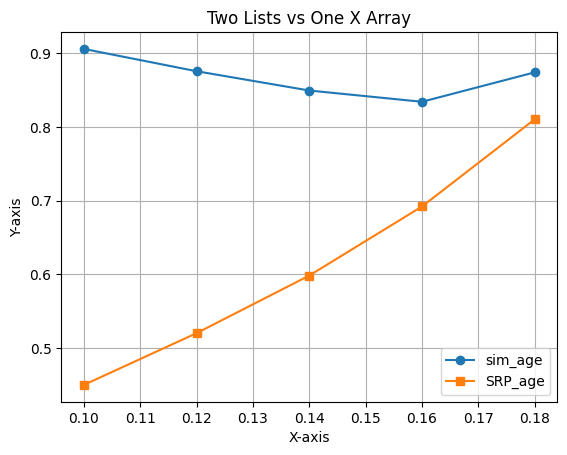

In [81]:
import matplotlib.pyplot as plt


plt.plot(sigma_arr[:], sim_age[:], marker='o', label='sim_age')
plt.plot(sigma_arr[:], SRP_age[:], marker='s', label='SRP_age')

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Two Lists vs One X Array')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
h_bad = 0.1
h_good = 1.0
h_values = [h_bad, h_good]
h = np.array(list(product(h_values, repeat=n_user)), dtype=np.float64)


import numpy as np
from scipy.stats import truncnorm
import time

def fix_sum_to_one(p):
    p = np.array(p, dtype=float)
    diff = 1.0 - p.sum()
    idx = np.argmax(p)
    p[idx] += diff
    return p


def trunc_error(sigma, low=-0.03, high=0.03, size=None):
    if sigma == 0:
        return np.zeros(size)
    a = low / sigma
    b = high / sigma
    return truncnorm.rvs(
        a,
        b,
        loc=0,
        scale=sigma,
        size=size
    )


def get_optimal_decoding_order(beta, h_val):
    beta = np.array(beta, dtype=float)
    h_val = np.array(h_val, dtype=float)
    return np.argsort(beta / h_val)


def cal_pow(R, DO, h_val):
    pow_vals = np.zeros(len(DO))
    for i in range(len(DO)):
        idx = DO[i]
        sum_i_M = np.sum([
            R[DO[k]]
            for k in range(i, len(DO))
        ])
        if i == len(DO) - 1:
            sum_ip1_M = 0
        else:
            sum_ip1_M = np.sum([
                R[DO[k]]
                for k in range(i + 1, len(DO))
            ])
        pow_vals[idx] = (
            2**(sum_i_M)
            -
            2**(sum_ip1_M)
        ) / h_val[idx]
    return pow_vals


def check_success_sic(hr, powers, rates, order):
    M = len(order)
    success = np.zeros(M, dtype=int)
    for j in range(M):
        user_j = order[j]
        signal = hr[user_j] * powers[user_j]
        interference = 0.0
        for k in range(j + 1, M):
            user_k = order[k]
            interference += (
                hr[user_k] * powers[user_k]
            )
        sinr = signal / (1 + interference)
        achievable_rate = np.log2(1 + sinr)
        # if achievable_rate >= rates[user_j]:
        #     success[user_j] = 1

        eps = 1e-10

        if achievable_rate + eps >= rates[user_j]:
            success[user_j] = 1
    return success


T = 100000
M = n_user


age = np.zeros(M)
sum_age = np.zeros(M)
fail_count = 0
total_tx = 0
sum_time = 0
print('\n========================')
print('sigma =', sigma)
print('========================')
for t in range(1, T + 1):
    t_start = time.time()
    pkts = np.random.choice(
        [1, 0],
        size=M,
        p=[pkt_prob, 1 - pkt_prob]        )
    h_val_test = np.random.choice(
        [0.1, 1],
        size=M,
        p=[0.5, 0.5]        )
    e = trunc_error(
        sigma=sigma,
        low=-0.03,
        high=0.03,
        size=M        )

    hr = h_val_test + e
    idx = np.where(
        np.all(
            np.isclose(h, h_val_test),
            axis=1
        )        )[0]

    if len(idx) == 0:
        continue
    idx_h = idx[0]
    age += pkts
    rho_idx = np.random.choice(
        np.arange(len(W)),
        size=1,
        p=fix_sum_to_one(erg_mu[idx_h])
    )
    idx_rho = rho_idx[0]
    best_bits = np.array(W[idx_rho])

    h_eff = np.maximum(
    h_val_test - 1*sigma,
    1e-6        )

    order = get_optimal_decoding_order(
        beta=lambda_k,
        h_val=h_eff        )

    powers = cal_pow(
        R=best_bits,
        DO=order,
        h_val=h_eff        )

    success = check_success_sic(
        hr=hr,
        powers=powers,
        rates=best_bits,
        order=order        )

    # if t%1000 == 0:
    #     print(h_eff, hr, order, powers,  best_bits, success)

    total_tx += np.sum(best_bits > 0)
    fail_count += np.sum(
        (best_bits > 0) & (success == 0)        )
    # age = age * np.where(success > 0, 0, 1)
    success_reset = (success > 0) & (best_bits > 0)
    age = age * np.where(success_reset, 0, 1)
    sum_age += age
    sum_time += (time.time() - t_start)
    # if t % 10000 == 0:
    #     avg_vaoi = np.mean(sum_age) / t
    #     fail_prob = fail_count / max(total_tx, 1)
    #     print(
    #         't =',
    #         t,
    #         'Avg VAoI =',
    #         np.round(avg_vaoi, 4),
    #         'Failure Prob =',
    #         np.round(fail_prob, 4)
    #     )

avg_vaoi = np.mean(sum_age) / T
fail_prob = fail_count / max(total_tx, 1)
print('\nFINAL RESULTS')
print(
    'Average VAoI =',
    np.round(avg_vaoi, 4)    )
print(
    'Failure Probability =',
    np.round(fail_prob, 4)    )
print(
    'Average Computation Time =',
    np.round(sum_time / T, 6),        'sec'
)


sigma = 0.05
t = 10000 Avg VAoI = 0.8757 Failure Prob = 0.0897
t = 20000 Avg VAoI = 0.8636 Failure Prob = 0.0897
t = 30000 Avg VAoI = 0.8674 Failure Prob = 0.0904
t = 40000 Avg VAoI = 0.8674 Failure Prob = 0.0902
t = 50000 Avg VAoI = 0.8662 Failure Prob = 0.0906
t = 60000 Avg VAoI = 0.8644 Failure Prob = 0.0908
t = 70000 Avg VAoI = 0.8642 Failure Prob = 0.0912
t = 80000 Avg VAoI = 0.8622 Failure Prob = 0.0911
t = 90000 Avg VAoI = 0.8609 Failure Prob = 0.0911
t = 100000 Avg VAoI = 0.8617 Failure Prob = 0.0909

FINAL RESULTS
Average VAoI = 0.8617
Failure Probability = 0.0909
Average Computation Time = 0.000196 sec
